In [26]:
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import torch
from pytorch_lightning import LightningModule
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger


from scipy.stats import kendalltau, pearsonr, spearmanr
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer, AdamW, get_linear_schedule_with_warmup
from transformers.tokenization_utils_base import BatchEncoding
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [27]:
logger = TensorBoardLogger("logs/", name="bert_finetuning")

trainer = pl.Trainer(
    max_epochs=3,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    logger=logger 
    )

torch.set_float32_matmul_precision('high')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [28]:
ruddit_df = pd.read_csv("ruddit_comments_score.csv")
ruddit_df['label'] = 0 # Original data
ruddit_df.drop(columns=['comment_id', 'score'], inplace=True)
print(ruddit_df.shape)
ruddit_df.head()

(5966, 2)


,body,label
0,> The difference in average earnings between m...,0
1,"The myth is that the ""gap"" is entirely based o...",0
2,[deleted],0
3,The assertion is that women get paid less for ...,0
4,You said in the OP that's not what they're mea...,0


In [29]:
orig_train_df = pd.read_csv("train.csv")
orig_train_df['label'] = 0 # Original data
print("Train: ", orig_train_df.shape)
orig_valid_df = pd.read_csv("valid.csv")
orig_valid_df['label'] = 0 # Original data
print("Valid: ", orig_valid_df.shape)
orig_test_df = pd.read_csv("test.csv")
orig_test_df['label'] = 0 # Original data
print("Test: ", orig_test_df.shape)

Train:  (4120, 5)
Valid:  (458, 5)
Test:  (1144, 5)


In [30]:
class CommentDataset(Dataset):
    def __init__(self, comments, labels, tokenizer, max_len=128):
        self.comments = comments
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.comments)

    def __getitem__(self, idx):
        comment = str(self.comments[idx])
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            comment,
            add_special_tokens=True,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),  # (1, max_len) → (max_len)
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }
        
class CommentClassifier(pl.LightningModule):
    def __init__(self, num_classes=2, pretrained_model="bert-base-uncased", lr=2e-5):
        super().__init__()
        self.save_hyperparameters()

        # Charger le modèle BERT pré-entraîné
        self.bert = BertModel.from_pretrained(pretrained_model)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)
        self.loss_fn = nn.CrossEntropyLoss()

        # Stocker les pertes et l'accuracy pour le graphique
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []
        self.epoch_train_losses = []
        self.epoch_val_losses = []
        self.epoch_train_accs = []
        self.epoch_val_accs = []


    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output  # Utilisation du token [CLS]
        output = self.dropout(pooled_output)
        return self.fc(output)

    def training_step(self, batch, batch_idx):
        input_ids, attention_mask, labels = batch["input_ids"], batch["attention_mask"], batch["label"]
        outputs = self(input_ids, attention_mask)
        loss = self.loss_fn(outputs, labels)

        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)

        # Sauvegarde des valeurs pour le graphique
        self.train_losses.append(loss.item())
        self.train_accs.append(acc.item())

        return loss

    def validation_step(self, batch, batch_idx):
        input_ids, attention_mask, labels = batch["input_ids"], batch["attention_mask"], batch["label"]
        outputs = self(input_ids, attention_mask)
        loss = self.loss_fn(outputs, labels)

        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

        # Sauvegarde des valeurs pour le graphique
        self.val_losses.append(loss.item())
        self.val_accs.append(acc.item())

        return loss

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr)

    def on_train_end(self):
        """Afficher le graphique des pertes et accuracy après l'entraînement."""
        min_epochs = min(len(self.epoch_train_losses), len(self.epoch_val_losses))

        epochs = range(1, min_epochs + 1)

        plt.figure(figsize=(12, 5))

        # Graphique de la loss
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.epoch_train_losses[:min_epochs], label="Train Loss")
        plt.plot(epochs, self.epoch_val_losses[:min_epochs], label="Val Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Évolution de la loss")
        plt.legend()

        # Graphique de l'accuracy
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.epoch_train_accs[:min_epochs], label="Train Acc")
        plt.plot(epochs, self.epoch_val_accs[:min_epochs], label="Val Acc")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.title("Évolution de l'accuracy")
        plt.legend()

        plt.show()

        
    def on_train_epoch_end(self):
        """Calculer la moyenne de la loss et accuracy par epoch"""
        avg_train_loss = sum(self.train_losses) / len(self.train_losses)
        avg_train_acc = sum(self.train_accs) / len(self.train_accs)

        self.epoch_train_losses.append(avg_train_loss)
        self.epoch_train_accs.append(avg_train_acc)

        self.train_losses = []  # Réinitialiser pour le prochain epoch
        self.train_accs = []

    def on_validation_epoch_end(self):
        """Calculer la moyenne de la loss et accuracy par epoch"""
        avg_val_loss = sum(self.val_losses) / len(self.val_losses)
        avg_val_acc = sum(self.val_accs) / len(self.val_accs)

        self.epoch_val_losses.append(avg_val_loss)
        self.epoch_val_accs.append(avg_val_acc)

        self.val_losses = []
        self.val_accs = []
        
    def test_step(self, batch, batch_idx):
        print("test_step called")  # Vérifier si la méthode est appelée
        input_ids, attention_mask, labels = batch["input_ids"], batch["attention_mask"], batch["label"]
        outputs = self(input_ids, attention_mask)
        loss = self.loss_fn(outputs, labels)

        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()

        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", acc, prog_bar=True)

        return {"test_loss": loss, "test_acc": acc}

def get_predictions(model, dataloader):
    """Retourne les labels réels et prédits pour le dataset de test."""
    model.eval()  # Mode évaluation
    y_true = []
    y_pred = []

    with torch.no_grad():  # Pas de calcul de gradients
        for batch in dataloader:
            input_ids, attention_mask, labels = batch["input_ids"], batch["attention_mask"], batch["label"]

            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)  # Prendre la classe avec la plus grande probabilité

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

In [15]:
synth_df = pd.read_csv("gpt2_unif.csv")
synth_df['label'] = 1 # Sythetic data
synth_df.drop(columns=['score'], inplace=True)
#sampled_synth_df = synth_df.sample(n=6000, random_state=42)
sampled_synth_train_df = synth_df.loc[synth_df.index.isin(orig_train_df['Unnamed: 0'])]
print(sampled_synth_train_df.shape)
sampled_synth_valid_df = synth_df.loc[synth_df.index.isin(orig_valid_df['Unnamed: 0'])]
print(sampled_synth_valid_df.shape)
sampled_synth_test_df = synth_df.loc[synth_df.index.isin(orig_test_df['Unnamed: 0'])]
print(sampled_synth_test_df.shape)
sampled_synth_valid_df.head()

(4120, 2)
(458, 2)
(1144, 2)


,body,label
16,I don't really disagree with either scenario ...,1
23,I have autism as a person that has very limit...,1
39,"We have a country (Russia), and so does m...",1
40,The last time when my friend stopped being up...,1
60,I'm confused.,1


In [17]:
gpt2_train_df = pd.concat([orig_train_df, sampled_synth_train_df]).sample(frac=1).reset_index(drop=True)
gpt2_train_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(gpt2_train_df.shape)
gpt2_valid_df = pd.concat([orig_valid_df, sampled_synth_valid_df]).sample(frac=1).reset_index(drop=True)
gpt2_valid_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(gpt2_valid_df.shape)
gpt2_test_df = pd.concat([orig_test_df, sampled_synth_test_df]).sample(frac=1).reset_index(drop=True)
gpt2_test_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(gpt2_test_df.shape)
gpt2_train_df.head()

(8240, 2)
(916, 2)
(2288, 2)


,body,label
0,A large-diseased bee is so strong it would ta...,1
1,you have no history. You are a dick of an ave...,1
2,It’s not a first amendment thing. It’s a 501c ...,0
3,"Fair point - that does make sense, just have a...",0
4,Weird the religious right is so worried about ...,0


In [ ]:
train_df = gpt2_train_df
val_df = gpt2_valid_df
test_df = gpt2_test_df

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Créer les datasets
train_dataset = CommentDataset(train_df.body.to_numpy(), train_df.label.to_numpy(), tokenizer)
val_dataset = CommentDataset(val_df.body.to_numpy(), val_df.label.to_numpy(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | bert    | BertModel        | 109 M  | eval 
1 | dropout | Dropout          | 0      | train
2 | fc      | Linear           | 1.5 K  | train
3 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
109 M     Trainable params
0         Non-trainable params
109 M     Total params
437.935   Total estimated model params size (MB)
3         Modules in train mode
228       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


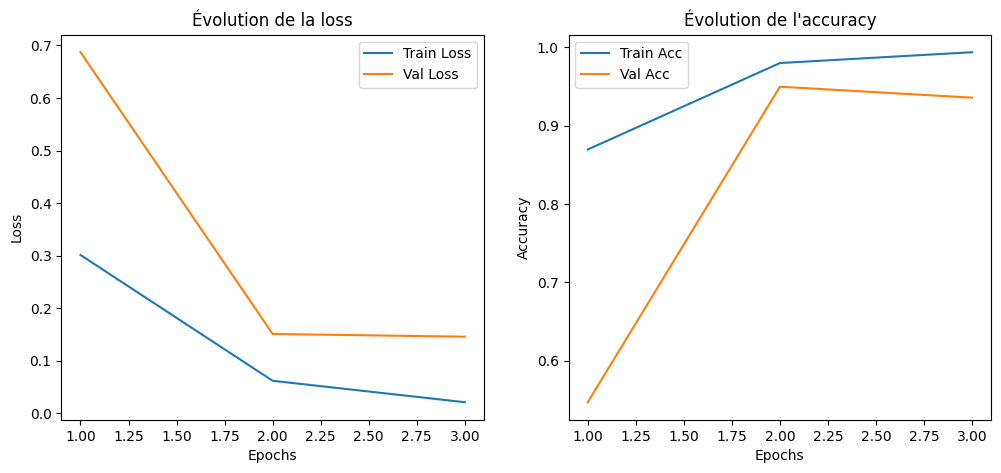

In [19]:
model = CommentClassifier()

trainer = pl.Trainer(
    max_epochs=3, 
    accelerator="gpu" if torch.cuda.is_available() else "cpu", 
    devices=1 if torch.cuda.is_available() else "auto"
)

trainer.fit(model, train_loader, val_loader)


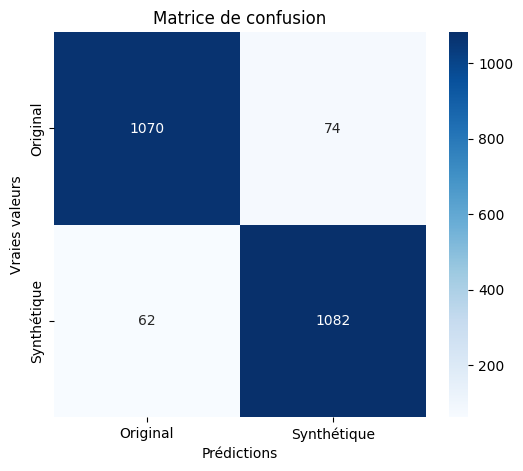

Accuracy: 0.9405594405594405
F1_score: 0.9408695652173913
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94      1144
           1       0.94      0.95      0.94      1144

    accuracy                           0.94      2288
   macro avg       0.94      0.94      0.94      2288
weighted avg       0.94      0.94      0.94      2288



In [20]:
test_dataset = CommentDataset(test_df.body.to_numpy(), test_df.label.to_numpy(), tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

model.eval()

# Récupérer les prédictions
y_true, y_pred = get_predictions(model, test_loader)
# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Créer une heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Original", "Synthétique"], yticklabels=["Original", "Synthétique"])
plt.xlabel("Prédictions")
plt.ylabel("Vraies valeurs")
plt.title("Matrice de confusion")
plt.show()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1_score:", f1_score(y_pred=y_pred, y_true=y_true))
print("Classification Report:\n", classification_report(y_true, y_pred))


In [9]:
synth_df = pd.read_csv("reform_lama3.1-uncessoredV2.csv")
synth_df['label'] = 1 # Sythetic data
synth_df = synth_df.rename(columns={'bidy': 'body'})

sampled_synth_train_df = synth_df.loc[synth_df.index.isin(orig_train_df['Unnamed: 0'])]

print(sampled_synth_train_df.shape)
sampled_synth_valid_df = synth_df.loc[synth_df.index.isin(orig_valid_df['Unnamed: 0'])]
print(sampled_synth_valid_df.shape)
sampled_synth_test_df = synth_df.loc[synth_df.index.isin(orig_test_df['Unnamed: 0'])]
print(sampled_synth_test_df.shape)
sampled_synth_valid_df.head()

(4120, 3)
(458, 3)
(1144, 3)


,body,score,label
16,"Apparently, it's now standard practice to sacr...",-0.064,1
23,"TIL facts are indeed facts, and education can ...",-0.208,1
39,My fingers are crossed that things keep rollin...,-0.792,1
40,"You think you're being misunderstood, but real...",0.396,1
60,The voters cast their ballots through a system...,-0.354,1


In [10]:
llama_train_df = pd.concat([orig_train_df, sampled_synth_train_df]).sample(frac=1).reset_index(drop=True)
llama_train_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(llama_train_df.shape)
llama_valid_df = pd.concat([orig_valid_df, sampled_synth_valid_df]).sample(frac=1).reset_index(drop=True)
llama_valid_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(llama_valid_df.shape)
llama_test_df = pd.concat([orig_test_df, sampled_synth_test_df]).sample(frac=1).reset_index(drop=True)
llama_test_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(llama_test_df.shape)
llama_train_df.head()

(8240, 2)
(916, 2)
(2288, 2)


,body,label
0,As much as I think it’s very possible that Ing...,0
1,Camel's primary use is as a work-animal. It's ...,0
2,"For me, saying anything is a mood killer. ""Oh,...",0
3,"I'm dragonflies are way scarier than spiders, ...",0
4,"Measles typically takes around 7-14 days, not ...",1


In [11]:
train_df = llama_train_df
val_df = llama_valid_df
test_df = llama_test_df

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Créer les datasets
train_dataset = CommentDataset(train_df.body.to_numpy(), train_df.label.to_numpy(), tokenizer)
val_dataset = CommentDataset(val_df.body.to_numpy(), val_df.label.to_numpy(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | bert    | BertModel        | 109 M  | eval 
1 | dropout | Dropout          | 0      | train
2 | fc      | Linear           | 1.5 K  | train
3 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
109 M     Trainable params
0         Non-trainable params
109 M     Total params
437.935   Total estimated model params size (MB)
3         Modules in train mode
228       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


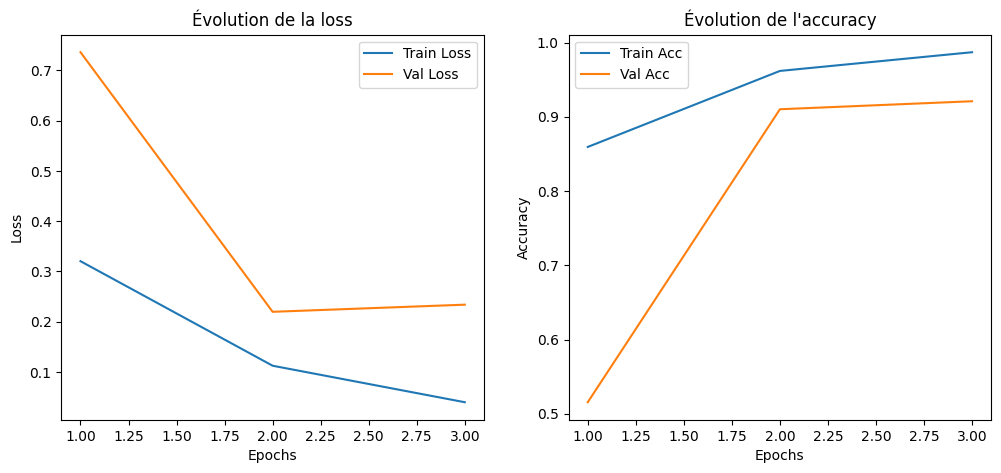

In [13]:
model = CommentClassifier()

trainer = pl.Trainer(
    max_epochs=3, 
    accelerator="gpu" if torch.cuda.is_available() else "cpu", 
    devices=1 if torch.cuda.is_available() else "auto"
)

trainer.fit(model, train_loader, val_loader)

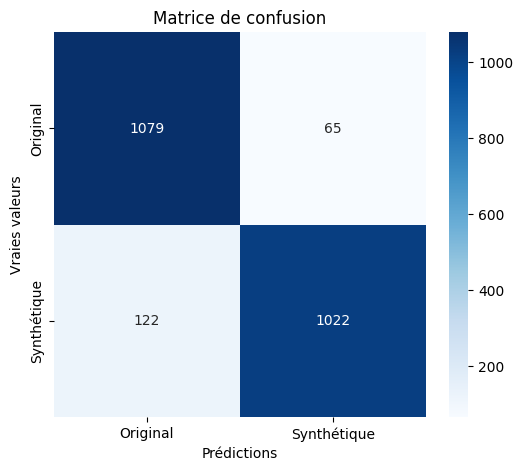

Accuracy: 0.9182692307692307
F1_score: 0.9161810847153743
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92      1144
           1       0.94      0.89      0.92      1144

    accuracy                           0.92      2288
   macro avg       0.92      0.92      0.92      2288
weighted avg       0.92      0.92      0.92      2288



In [14]:
test_dataset = CommentDataset(test_df.body.to_numpy(), test_df.label.to_numpy(), tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

model.eval()

# Récupérer les prédictions
y_true, y_pred = get_predictions(model, test_loader)
# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Créer une heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Original", "Synthétique"], yticklabels=["Original", "Synthétique"])
plt.xlabel("Prédictions")
plt.ylabel("Vraies valeurs")
plt.title("Matrice de confusion")
plt.show()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1_score:", f1_score(y_pred=y_pred, y_true=y_true))
print("Classification Report:\n", classification_report(y_true, y_pred))

In [7]:
synth_df = pd.read_csv("back_translated_comments-1.csv")
synth_df['label'] = 1 # Sythetic data
#synth_df = synth_df.rename(columns={'bidy': 'body'})

#sampled_synth_train_df = synth_df.loc[synth_df.index.isin(orig_train_df['Unnamed: 0'])]
print(synth_df.shape)
# Mélanger tout le DataFrame
df_shuffled = synth_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Répartition des jeux de données
sampled_synth_train_df = df_shuffled.iloc[:2966]
sampled_synth_valid_df = df_shuffled.iloc[2966:3296]
sampled_synth_test_df = df_shuffled.iloc[3296:]


print(sampled_synth_train_df.shape)
#sampled_synth_valid_df = synth_df.loc[synth_df.index.isin(orig_valid_df['Unnamed: 0'])]
print(sampled_synth_valid_df.shape)
#sampled_synth_test_df = synth_df.loc[synth_df.index.isin(orig_test_df['Unnamed: 0'])]
print(sampled_synth_test_df.shape)
sampled_synth_train_df.head()

(4120, 3)
(2966, 3)
(330, 3)
(824, 3)


,body,score,label
0,"Let’s help global health care, and tribal dict...",0.596,1
1,Every website you recognize is a wholly owned ...,-0.271,1
2,I read the dog like a father... totally confus...,-0.188,1
3,Who only speaks English?,-0.200,1
4,How did you know they’re cheating on you and t...,0.250,1


In [16]:
orig_trdf = orig_train_df[:2966]
orig_vldf = orig_valid_df[:330]
orig_ttdf = orig_test_df[:824]
BT_1_train_df = pd.concat([orig_trdf, sampled_synth_train_df]).sample(frac=1).reset_index(drop=True)
BT_1_train_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(BT_1_train_df.shape)
BT_1_valid_df = pd.concat([orig_vldf, sampled_synth_valid_df]).sample(frac=1).reset_index(drop=True)
BT_1_valid_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(BT_1_valid_df.shape)
BT_1_test_df = pd.concat([orig_ttdf, sampled_synth_test_df]).sample(frac=1).reset_index(drop=True)
BT_1_test_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(BT_1_test_df.shape)
BT_1_train_df.head()

(5932, 2)
(660, 2)
(1648, 2)


,body,label
0,I don’t know if hey are becoming a culture as ...,0
1,But putting them on a plane is almost impossib...,1
2,You seem to be unable to change your opinion.T...,1
3,Do you have a special link?,1
4,"Many of them are extremists, and according to ...",1


In [17]:
train_df = BT_1_train_df
val_df = BT_1_valid_df
test_df = BT_1_test_df

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Créer les datasets
train_dataset = CommentDataset(train_df.body.to_numpy(), train_df.label.to_numpy(), tokenizer)
val_dataset = CommentDataset(val_df.body.to_numpy(), val_df.label.to_numpy(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | bert    | BertModel        | 109 M  | eval 
1 | dropout | Dropout          | 0      | train
2 | fc      | Linear           | 1.5 K  | train
3 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
109 M     Trainable params
0         Non-trainable params
109 M     Total params
437.935   Total estimated model params size (MB)
3         Modules in train mode
228       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


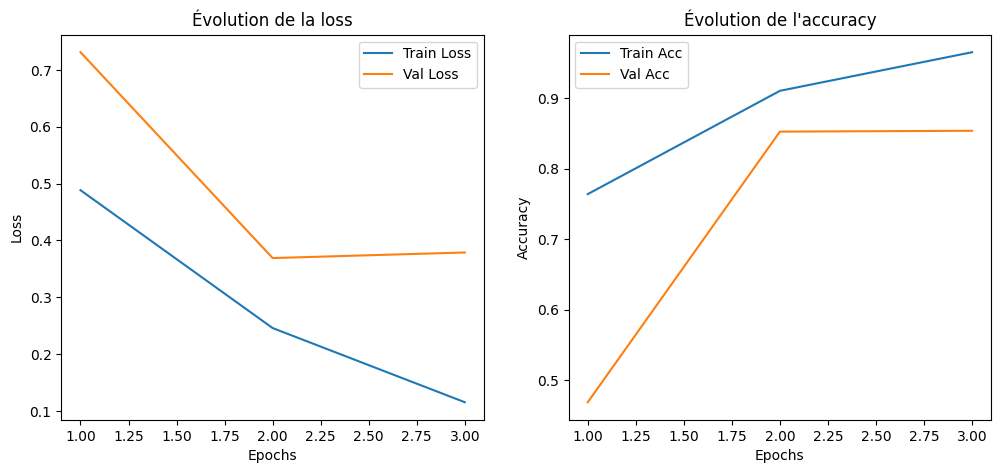

In [18]:
model = CommentClassifier()

trainer = pl.Trainer(
    max_epochs=3, 
    accelerator="gpu" if torch.cuda.is_available() else "cpu", 
    devices=1 if torch.cuda.is_available() else "auto"
)

trainer.fit(model, train_loader, val_loader)

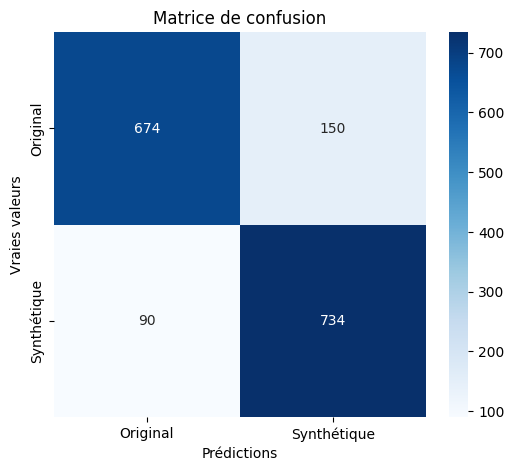

Accuracy: 0.8543689320388349
F1_score: 0.8594847775175644
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.82      0.85       824
           1       0.83      0.89      0.86       824

    accuracy                           0.85      1648
   macro avg       0.86      0.85      0.85      1648
weighted avg       0.86      0.85      0.85      1648



In [21]:
test_dataset = CommentDataset(test_df.body.to_numpy(), test_df.label.to_numpy(), tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

model.eval()

# Récupérer les prédictions
y_true, y_pred = get_predictions(model, test_loader)
# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Créer une heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Original", "Synthétique"], yticklabels=["Original", "Synthétique"])
plt.xlabel("Prédictions")
plt.ylabel("Vraies valeurs")
plt.title("Matrice de confusion")
plt.show()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1_score:", f1_score(y_pred=y_pred, y_true=y_true))
print("Classification Report:\n", classification_report(y_true, y_pred))

In [6]:
synth_df = pd.read_csv("back_translated_comments-2.csv")
synth_df['label'] = 1 # Sythetic data
#synth_df = synth_df.rename(columns={'bidy': 'body'})

#sampled_synth_train_df = synth_df.loc[synth_df.index.isin(orig_train_df['Unnamed: 0'])]
print(synth_df.shape)
# Mélanger tout le DataFrame
df_shuffled = synth_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Répartition des jeux de données
sampled_synth_train_df = df_shuffled.iloc[:2966]
sampled_synth_valid_df = df_shuffled.iloc[2966:3296]
sampled_synth_test_df = df_shuffled.iloc[3296:]


print(sampled_synth_train_df.shape)
#sampled_synth_valid_df = synth_df.loc[synth_df.index.isin(orig_valid_df['Unnamed: 0'])]
print(sampled_synth_valid_df.shape)
#sampled_synth_test_df = synth_df.loc[synth_df.index.isin(orig_test_df['Unnamed: 0'])]
print(sampled_synth_test_df.shape)

orig_trdf = orig_train_df[:2966]
orig_vldf = orig_valid_df[:330]
orig_ttdf = orig_test_df[:824]
BT_2_train_df = pd.concat([orig_trdf, sampled_synth_train_df]).sample(frac=1).reset_index(drop=True)
BT_2_train_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(BT_2_train_df.shape)
BT_2_valid_df = pd.concat([orig_vldf, sampled_synth_valid_df]).sample(frac=1).reset_index(drop=True)
BT_2_valid_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(BT_2_valid_df.shape)
BT_2_test_df = pd.concat([orig_ttdf, sampled_synth_test_df]).sample(frac=1).reset_index(drop=True)
BT_2_test_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(BT_2_test_df.shape)
BT_2_train_df.head()

(4120, 3)
(2966, 3)
(330, 3)
(824, 3)
(5932, 2)
(660, 2)
(1648, 2)


,body,label
0,> And most people in videos are taken by surpr...,0
1,"One more grail and medeas at 90, and jing ke w...",0
2,Many struggles were paid to keep the company h...,1
3,"It's an important point, though. Is prison rap...",0
4,> I'll prioritize crisp good sound\n\nMSR7 wou...,0


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | bert    | BertModel        | 109 M  | eval 
1 | dropout | Dropout          | 0      | train
2 | fc      | Linear           | 1.5 K  | train
3 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
109 M     Trainable params
0         Non-trainable params
109 M     Total params
437.935   Total estimated model params size (MB)
3         Modules in train mode
228       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


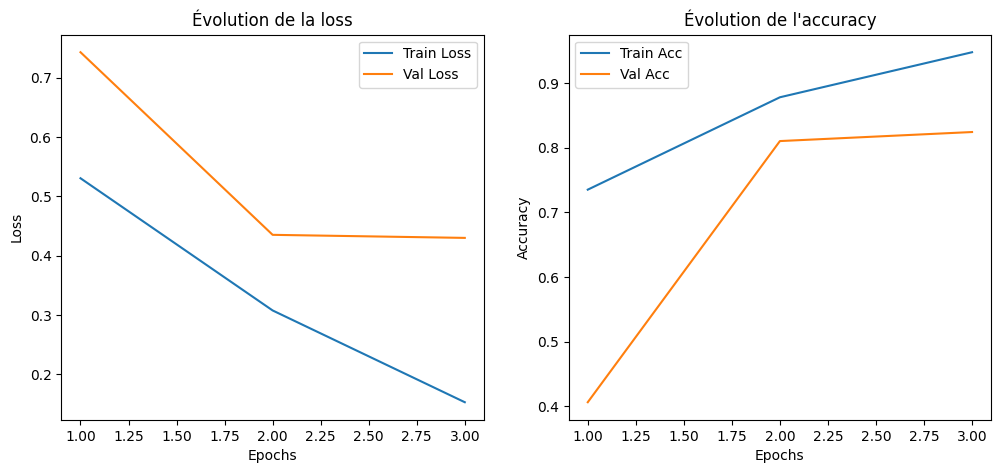

In [7]:
train_df = BT_2_train_df
val_df = BT_2_valid_df
test_df = BT_2_test_df

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Créer les datasets
train_dataset = CommentDataset(train_df.body.to_numpy(), train_df.label.to_numpy(), tokenizer)
val_dataset = CommentDataset(val_df.body.to_numpy(), val_df.label.to_numpy(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

model = CommentClassifier()

trainer = pl.Trainer(
    max_epochs=3, 
    accelerator="gpu" if torch.cuda.is_available() else "cpu", 
    devices=1 if torch.cuda.is_available() else "auto"
)

trainer.fit(model, train_loader, val_loader)

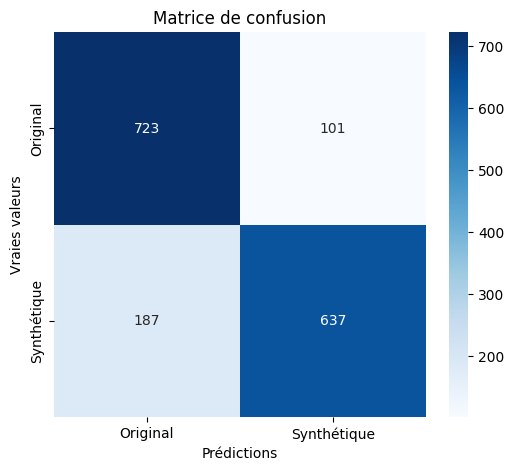

Accuracy: 0.8252427184466019
F1_score: 0.8156209987195903
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83       824
           1       0.86      0.77      0.82       824

    accuracy                           0.83      1648
   macro avg       0.83      0.83      0.82      1648
weighted avg       0.83      0.83      0.82      1648



In [8]:
test_dataset = CommentDataset(test_df.body.to_numpy(), test_df.label.to_numpy(), tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

model.eval()

# Récupérer les prédictions
y_true, y_pred = get_predictions(model, test_loader)
# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Créer une heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Original", "Synthétique"], yticklabels=["Original", "Synthétique"])
plt.xlabel("Prédictions")
plt.ylabel("Vraies valeurs")
plt.title("Matrice de confusion")
plt.show()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1_score:", f1_score(y_pred=y_pred, y_true=y_true))
print("Classification Report:\n", classification_report(y_true, y_pred))

In [9]:
synth_df = pd.read_csv("back_translated_comments-3.csv")
synth_df['label'] = 1 # Sythetic data
#synth_df = synth_df.rename(columns={'bidy': 'body'})

#sampled_synth_train_df = synth_df.loc[synth_df.index.isin(orig_train_df['Unnamed: 0'])]
print(synth_df.shape)
# Mélanger tout le DataFrame
df_shuffled = synth_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Répartition des jeux de données
sampled_synth_train_df = df_shuffled.iloc[:2966]
sampled_synth_valid_df = df_shuffled.iloc[2966:3296]
sampled_synth_test_df = df_shuffled.iloc[3296:]


print(sampled_synth_train_df.shape)
#sampled_synth_valid_df = synth_df.loc[synth_df.index.isin(orig_valid_df['Unnamed: 0'])]
print(sampled_synth_valid_df.shape)
#sampled_synth_test_df = synth_df.loc[synth_df.index.isin(orig_test_df['Unnamed: 0'])]
print(sampled_synth_test_df.shape)

orig_trdf = orig_train_df[:2966]
orig_vldf = orig_valid_df[:330]
orig_ttdf = orig_test_df[:824]
BT_3_train_df = pd.concat([orig_trdf, sampled_synth_train_df]).sample(frac=1).reset_index(drop=True)
BT_3_train_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(BT_3_train_df.shape)
BT_3_valid_df = pd.concat([orig_vldf, sampled_synth_valid_df]).sample(frac=1).reset_index(drop=True)
BT_3_valid_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(BT_3_valid_df.shape)
BT_3_test_df = pd.concat([orig_ttdf, sampled_synth_test_df]).sample(frac=1).reset_index(drop=True)
BT_3_test_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(BT_3_test_df.shape)
BT_3_train_df.head()

(4120, 3)
(2966, 3)
(330, 3)
(824, 3)
(5932, 2)
(660, 2)
(1648, 2)


,body,label
0,"If you want to make Russia look bad, I think t...",1
1,It is a shitty thing for someone to do whether...,0
2,"I’m not saying so, but when age starts to be a...",1
3,To harass someone is to be blamed for any kind...,1
4,He climbed the Willis Tower Skydeck and stood ...,1


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | bert    | BertModel        | 109 M  | eval 
1 | dropout | Dropout          | 0      | train
2 | fc      | Linear           | 1.5 K  | train
3 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
109 M     Trainable params
0         Non-trainable params
109 M     Total params
437.935   Total estimated model params size (MB)
3         Modules in train mode
228       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


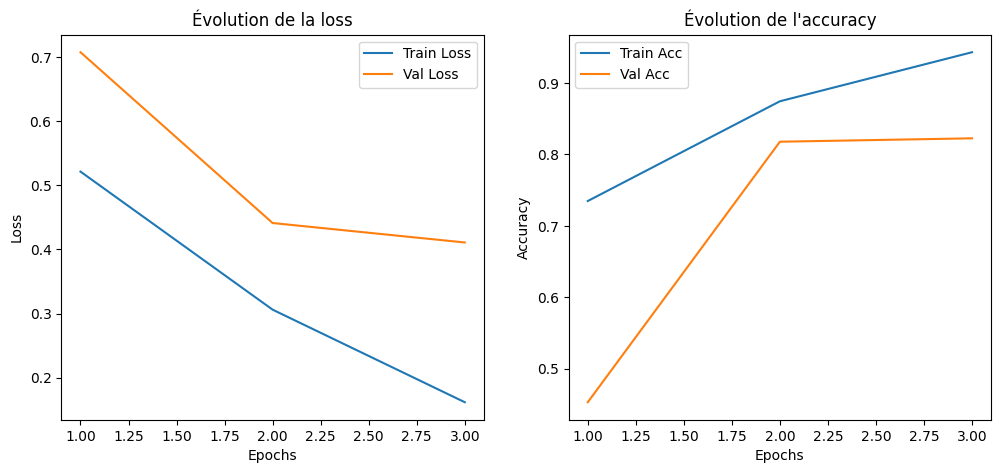

In [10]:
train_df = BT_3_train_df
val_df = BT_3_valid_df
test_df = BT_3_test_df

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Créer les datasets
train_dataset = CommentDataset(train_df.body.to_numpy(), train_df.label.to_numpy(), tokenizer)
val_dataset = CommentDataset(val_df.body.to_numpy(), val_df.label.to_numpy(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

model = CommentClassifier()

trainer = pl.Trainer(
    max_epochs=3, 
    accelerator="gpu" if torch.cuda.is_available() else "cpu", 
    devices=1 if torch.cuda.is_available() else "auto"
)

trainer.fit(model, train_loader, val_loader)

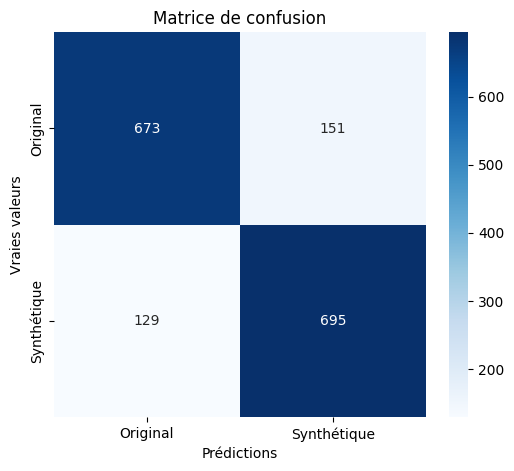

Accuracy: 0.8300970873786407
F1_score: 0.8323353293413174
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.82      0.83       824
           1       0.82      0.84      0.83       824

    accuracy                           0.83      1648
   macro avg       0.83      0.83      0.83      1648
weighted avg       0.83      0.83      0.83      1648



In [11]:
test_dataset = CommentDataset(test_df.body.to_numpy(), test_df.label.to_numpy(), tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

model.eval()

# Récupérer les prédictions
y_true, y_pred = get_predictions(model, test_loader)
# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Créer une heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Original", "Synthétique"], yticklabels=["Original", "Synthétique"])
plt.xlabel("Prédictions")
plt.ylabel("Vraies valeurs")
plt.title("Matrice de confusion")
plt.show()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1_score:", f1_score(y_pred=y_pred, y_true=y_true))
print("Classification Report:\n", classification_report(y_true, y_pred))

In [6]:
synth_df = pd.read_csv("Llama32Generate.csv")
synth_df['label'] = 1 # Sythetic data
synth_df = synth_df.rename(columns={'bidy': 'body'})

sampled_synth_train_df = synth_df.loc[synth_df.index.isin(orig_train_df['Unnamed: 0'])]

print(sampled_synth_train_df.shape)
sampled_synth_valid_df = synth_df.loc[synth_df.index.isin(orig_valid_df['Unnamed: 0'])]
print(sampled_synth_valid_df.shape)
sampled_synth_test_df = synth_df.loc[synth_df.index.isin(orig_test_df['Unnamed: 0'])]
print(sampled_synth_test_df.shape)
sampled_synth_valid_df.head()

(4120, 4)
(458, 4)
(1144, 4)


,comment_id,body,score,label
16,llama16,I don't seem to have a link to an online anal...,0.230150,1
23,llama23,>100.0. That’s why it’s worth taking this vie...,0.550839,1
39,llama39,-42.0,0.484211,1
40,llama40,27.4\n\nedit:\n\nAre you referring to this ex...,0.257348,1
60,llama60,\n\nEdit:,0.189405,1


In [7]:
llama_gen_train_df = pd.concat([orig_train_df, sampled_synth_train_df]).sample(frac=1).reset_index(drop=True)
llama_gen_train_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(llama_gen_train_df.shape)
llama_gen_valid_df = pd.concat([orig_valid_df, sampled_synth_valid_df]).sample(frac=1).reset_index(drop=True)
llama_gen_valid_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(llama_gen_valid_df.shape)
llama_gen_test_df = pd.concat([orig_test_df, sampled_synth_test_df]).sample(frac=1).reset_index(drop=True)
llama_gen_test_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(llama_gen_test_df.shape)
llama_gen_train_df.head()

(8240, 2)
(916, 2)
(2288, 2)


,body,label
0,25.0),1
1,Some of us in the US are very wondering of thi...,0
2,Well I disagree wildly that fake news had an e...,0
3,It would have been whatever the default versio...,0
4,"11s, I don't agree, because that's your opini...",1


In [8]:
train_df = llama_gen_train_df
val_df = llama_gen_valid_df
test_df = llama_gen_test_df

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Créer les datasets
train_dataset = CommentDataset(train_df.body.to_numpy(), train_df.label.to_numpy(), tokenizer)
val_dataset = CommentDataset(val_df.body.to_numpy(), val_df.label.to_numpy(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | bert    | BertModel        | 109 M  | eval 
1 | dropout | Dropout          | 0      | train
2 | fc      | Linear           | 1.5 K  | train
3 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
109 M     Trainable params
0         Non-trainable params
109 M     Total params
437.935   Total estimated model params size (MB)
3         Modules in train mode
228       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


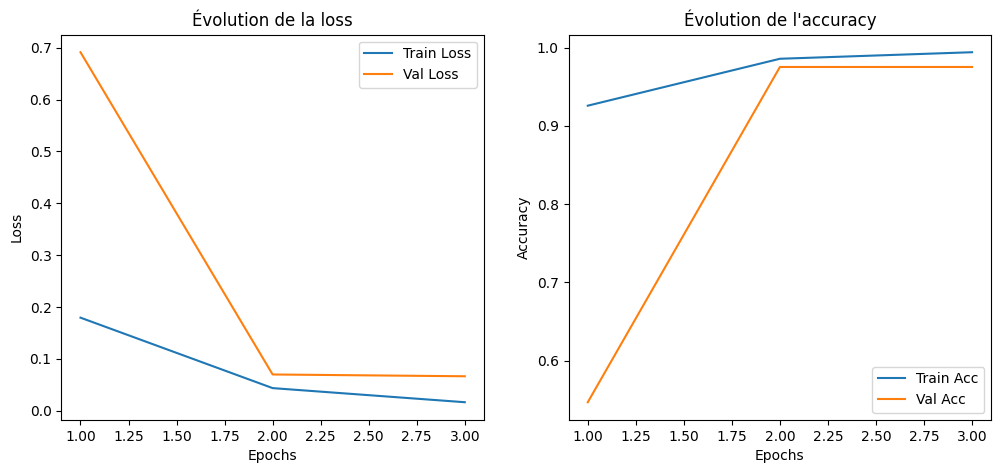

In [9]:
model = CommentClassifier()

trainer = pl.Trainer(
    max_epochs=3, 
    accelerator="gpu" if torch.cuda.is_available() else "cpu", 
    devices=1 if torch.cuda.is_available() else "auto"
)

trainer.fit(model, train_loader, val_loader)

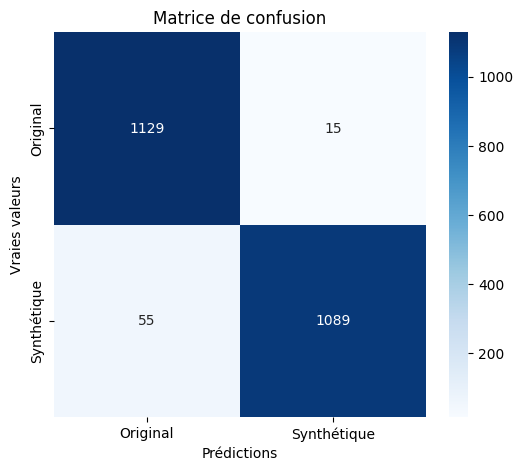

Accuracy: 0.9694055944055944
F1_score: 0.9688612099644128
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97      1144
           1       0.99      0.95      0.97      1144

    accuracy                           0.97      2288
   macro avg       0.97      0.97      0.97      2288
weighted avg       0.97      0.97      0.97      2288



In [10]:
test_dataset = CommentDataset(test_df.body.to_numpy(), test_df.label.to_numpy(), tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

model.eval()

# Récupérer les prédictions
y_true, y_pred = get_predictions(model, test_loader)
# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Créer une heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Original", "Synthétique"], yticklabels=["Original", "Synthétique"])
plt.xlabel("Prédictions")
plt.ylabel("Vraies valeurs")
plt.title("Matrice de confusion")
plt.show()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1_score:", f1_score(y_pred=y_pred, y_true=y_true))
print("Classification Report:\n", classification_report(y_true, y_pred))

In [8]:
synth_df = pd.read_csv("few_shot_backward_fixed.csv")
synth_df['label'] = 1 # Sythetic data
synth_df = synth_df.rename(columns={'bidy': 'body'})

sampled_synth_train_df = synth_df.loc[synth_df.index.isin(orig_train_df['Unnamed: 0'])]

print(sampled_synth_train_df.shape)
sampled_synth_valid_df = synth_df.loc[synth_df.index.isin(orig_valid_df['Unnamed: 0'])]
print(sampled_synth_valid_df.shape)
sampled_synth_test_df = synth_df.loc[synth_df.index.isin(orig_test_df['Unnamed: 0'])]
print(sampled_synth_test_df.shape)
sampled_synth_valid_df.head()

(4120, 3)
(458, 3)
(1144, 3)


,body,score,label
16,It's a shame that it's so heavily monetized. I...,-0.347209,1
23,You absolute moron. Are you actually serious r...,1.000000,1
39,"You know, it's kind of sad to see so many peop...",0.286357,1
40,What a cool experience! Thanks for sharing.,-0.707764,1
60,The best way to learn is to practice! Keep at ...,-0.461446,1


In [9]:
FS_train_df = pd.concat([orig_train_df, sampled_synth_train_df]).sample(frac=1).reset_index(drop=True)
FS_train_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(FS_train_df.shape)
FS_valid_df = pd.concat([orig_valid_df, sampled_synth_valid_df]).sample(frac=1).reset_index(drop=True)
FS_valid_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(FS_valid_df.shape)
FS_test_df = pd.concat([orig_test_df, sampled_synth_test_df]).sample(frac=1).reset_index(drop=True)
FS_test_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(FS_test_df.shape)
FS_train_df.head()

(8240, 2)
(916, 2)
(2288, 2)


,body,label
0,None of my friends throw a New Year's eve part...,0
1,this has to be fake lmao,0
2,"I think about this Everytime I see it. Movies,...",0
3,Can't tell but seems the first part is sarcasm...,0
4,If only my IBS didnt ruin that business model ...,0


In [10]:
train_df = FS_train_df
val_df = FS_valid_df
test_df = FS_test_df

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Créer les datasets
train_dataset = CommentDataset(train_df.body.to_numpy(), train_df.label.to_numpy(), tokenizer)
val_dataset = CommentDataset(val_df.body.to_numpy(), val_df.label.to_numpy(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | bert    | BertModel        | 109 M  | eval 
1 | dropout | Dropout          | 0      | train
2 | fc      | Linear           | 1.5 K  | train
3 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
109 M     Trainable params
0         Non-trainable params
109 M     Total params
437.935   Total estimated model params size (MB)
3         Modules in train mode
228       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=2` reached.


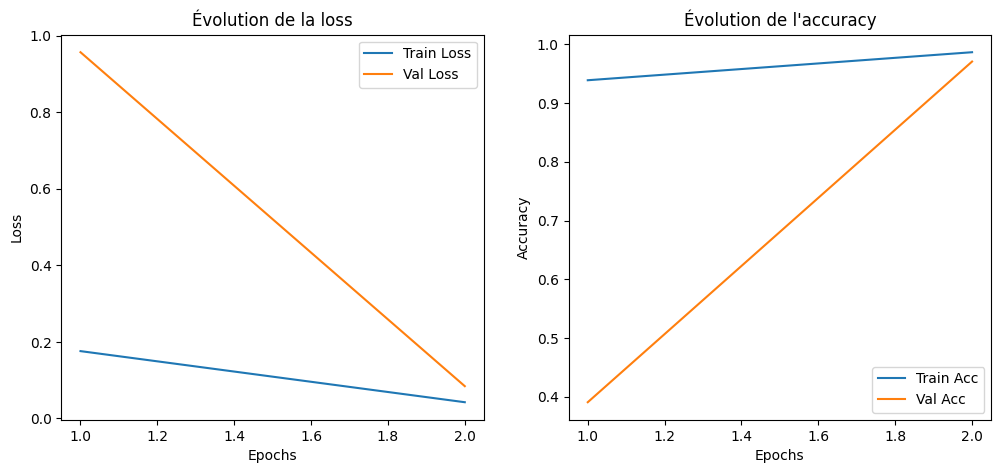

In [12]:
model = CommentClassifier()

trainer = pl.Trainer(
    max_epochs=2, 
    accelerator="gpu" if torch.cuda.is_available() else "cpu", 
    devices=1 if torch.cuda.is_available() else "auto"
)

trainer.fit(model, train_loader, val_loader)

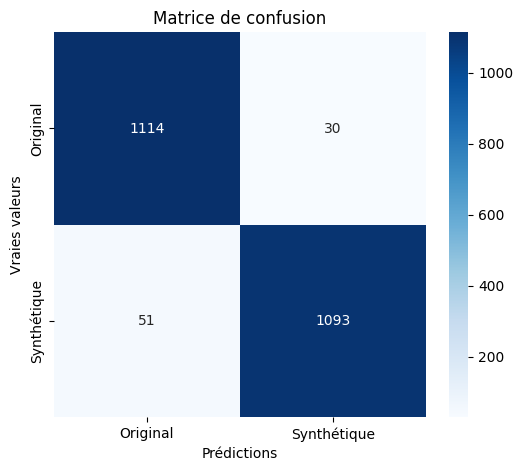

Accuracy: 0.9645979020979021
F1_score: 0.9642699602999559
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96      1144
           1       0.97      0.96      0.96      1144

    accuracy                           0.96      2288
   macro avg       0.96      0.96      0.96      2288
weighted avg       0.96      0.96      0.96      2288



In [13]:
test_dataset = CommentDataset(test_df.body.to_numpy(), test_df.label.to_numpy(), tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

model.eval()

# Récupérer les prédictions
y_true, y_pred = get_predictions(model, test_loader)
# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Créer une heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Original", "Synthétique"], yticklabels=["Original", "Synthétique"])
plt.xlabel("Prédictions")
plt.ylabel("Vraies valeurs")
plt.title("Matrice de confusion")
plt.show()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1_score:", f1_score(y_pred=y_pred, y_true=y_true))
print("Classification Report:\n", classification_report(y_true, y_pred))

In [32]:
synth_df_BT_1 = pd.read_csv("back_translated_comments-1.csv")
synth_df_BT_1 = synth_df_BT_1[:1373]
print(synth_df_BT_1.shape)
synth_df_BT_1

(1373, 2)


,body,score
0,Do you honestly think that new modeling tools ...,-0.208
1,Have you ever been to a place where there is a...,-0.146
2,"When you try to pinball on your computer, you ...",-0.312
3,Tell me about it on my Facebook news feed.,-0.479
4,"I didn’t sell it, I didn’t buy it.",-0.438
...,...,...
1368,"“The world will end in 12 years,” “climate cha...",0.188
1369,The problem is that wolves usually hunt in pac...,-0.542
1370,I did an internship in the last semester at th...,-0.333
1371,Is this submarine that does not speak of world...,0.021


In [33]:
synth_df_few_shots = pd.read_csv("few_shot_backward_fixed.csv")
synth_df_few_shots['label'] = 1 # Sythetic data
synth_df_few_shots.drop(columns=['score'], inplace=True)
sampled_synth_df_few_shots = synth_df_few_shots.sample(n=0, random_state=42)

synth_df_BT_1 = pd.read_csv("back_translated_comments-1.csv")
synth_df_BT_1['label'] = 1 # Sythetic data
synth_df_BT_1.drop(columns=['score'], inplace=True)
sampled_synth_df_BT_1 = synth_df_BT_1[:1373]

synth_df_BT_2 = pd.read_csv("back_translated_comments-2.csv")
synth_df_BT_2['label'] = 1 # Sythetic data
synth_df_BT_2.drop(columns=['score'], inplace=True)
sampled_synth_df_BT_2 = synth_df_BT_2[1373:2747]

synth_df_BT_3 = pd.read_csv("back_translated_comments-3.csv")
synth_df_BT_3['label'] = 1 # Sythetic data
synth_df_BT_3.drop(columns=['score'], inplace=True)
sampled_synth_df_BT_3 = synth_df_BT_3[2747:]

synth_df_llama = pd.read_csv("reform_lama3.1-uncessoredV2.csv")
synth_df_llama['label'] = 1 # Sythetic data
sampled_synth_df_llama = synth_df_llama.sample(n=0, random_state=42)
sampled_synth_df_llama = sampled_synth_df_llama.rename(columns={'bidy': 'body'})

synth_df_gpt2 = pd.read_csv("gpt2_unif.csv")
synth_df_gpt2['label'] = 1 # Sythetic data
synth_df_gpt2.drop(columns=['score'], inplace=True)
sampled_synth_df_gpt2 = synth_df_gpt2.sample(n=0, random_state=42)

synth_df_llama_gen = pd.read_csv("Llama32Generate.csv")
synth_df_llama_gen['label'] = 1 # Sythetic data
synth_df_llama_gen.drop(columns=['score'], inplace=True)
sampled_synth_df_llama_gen = synth_df_gpt2.sample(n=0, random_state=42)

sampled_synth_df = pd.concat([sampled_synth_df_few_shots, sampled_synth_df_BT_1, sampled_synth_df_BT_2, sampled_synth_df_BT_3, 
                              sampled_synth_df_llama, sampled_synth_df_gpt2, sampled_synth_df_llama_gen], axis=0, ignore_index=True)
print(sampled_synth_df.shape)
sampled_synth_df.head()

(4120, 3)


,body,label,score
0,Do you honestly think that new modeling tools ...,1,NaN
1,Have you ever been to a place where there is a...,1,NaN
2,"When you try to pinball on your computer, you ...",1,NaN
3,Tell me about it on my Facebook news feed.,1,NaN
4,"I didn’t sell it, I didn’t buy it.",1,NaN


In [34]:
sampled_synth_train_df, sampled_synth_test_df = train_test_split(sampled_synth_df, test_size=0.20, stratify=sampled_synth_df["label"], random_state=42)
sampled_synth_train_df, sampled_synth_valid_df = train_test_split(sampled_synth_train_df, test_size=0.08 / 0.8, stratify=sampled_synth_train_df["label"], random_state=42)

orig_trdf = orig_train_df[:2966]
orig_vldf = orig_valid_df[:330]
orig_ttdf = orig_test_df[:824]

BT_ALL_train_df = pd.concat([orig_trdf, sampled_synth_train_df]).sample(frac=1).reset_index(drop=True)
BT_ALL_train_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(BT_ALL_train_df.shape)
BT_ALL_valid_df = pd.concat([orig_vldf, sampled_synth_valid_df]).sample(frac=1).reset_index(drop=True)
BT_ALL_valid_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(BT_ALL_valid_df.shape)
BT_ALL_test_df = pd.concat([orig_ttdf, sampled_synth_test_df]).sample(frac=1).reset_index(drop=True)
BT_ALL_test_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(BT_ALL_test_df.shape)

train_df = BT_ALL_train_df
val_df = BT_ALL_valid_df
test_df = BT_ALL_test_df

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Créer les datasets
train_dataset = CommentDataset(train_df.body.to_numpy(), train_df.label.to_numpy(), tokenizer)
val_dataset = CommentDataset(val_df.body.to_numpy(), val_df.label.to_numpy(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

(5932, 2)
(660, 2)
(1648, 2)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | bert    | BertModel        | 109 M  | eval 
1 | dropout | Dropout          | 0      | train
2 | fc      | Linear           | 1.5 K  | train
3 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
109 M     Trainable params
0         Non-trainable params
109 M     Total params
437.935   Total estimated model params size (MB)
3         Modules in train mode
228       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


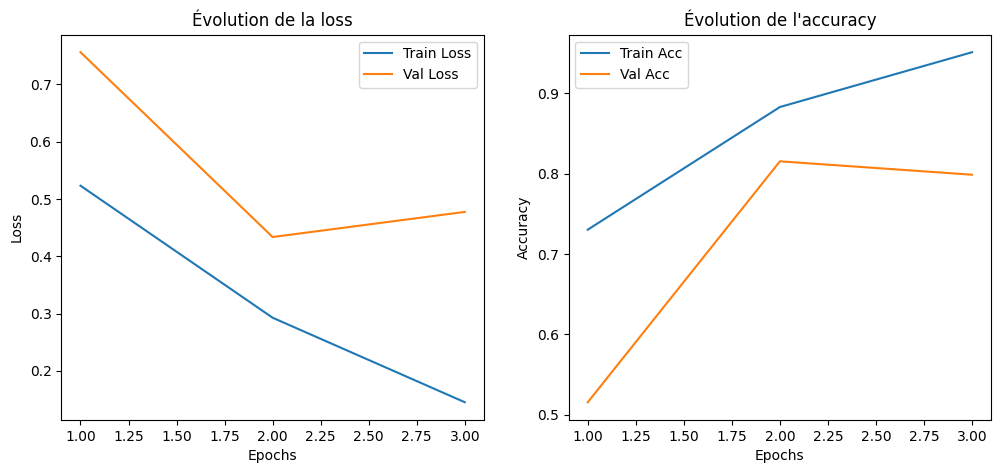

In [35]:
model = CommentClassifier()

trainer = pl.Trainer(
    max_epochs=3, 
    accelerator="gpu" if torch.cuda.is_available() else "cpu", 
    devices=1 if torch.cuda.is_available() else "auto"
)

trainer.fit(model, train_loader, val_loader)

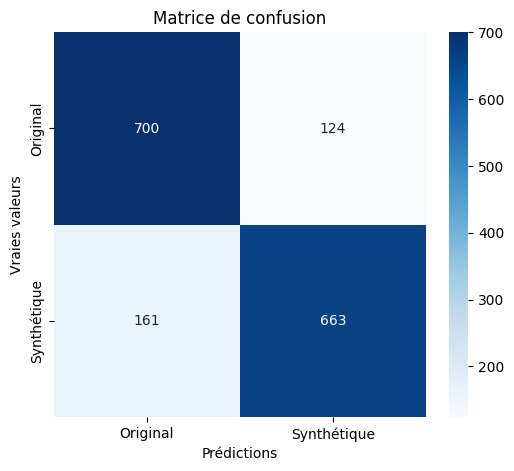

Accuracy: 0.8270631067961165
F1_score: 0.8230912476722533
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.85      0.83       824
           1       0.84      0.80      0.82       824

    accuracy                           0.83      1648
   macro avg       0.83      0.83      0.83      1648
weighted avg       0.83      0.83      0.83      1648



In [36]:
test_dataset = CommentDataset(test_df.body.to_numpy(), test_df.label.to_numpy(), tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

model.eval()

# Récupérer les prédictions
y_true, y_pred = get_predictions(model, test_loader)
# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Créer une heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Original", "Synthétique"], yticklabels=["Original", "Synthétique"])
plt.xlabel("Prédictions")
plt.ylabel("Vraies valeurs")
plt.title("Matrice de confusion")
plt.show()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1_score:", f1_score(y_pred=y_pred, y_true=y_true))
print("Classification Report:\n", classification_report(y_true, y_pred))

In [7]:
synth_df_few_shots = pd.read_csv("few_shot_backward_fixed.csv")
synth_df_few_shots['label'] = 1 # Sythetic data
synth_df_few_shots.drop(columns=['score'], inplace=True)
sampled_synth_df_few_shots = synth_df_few_shots.sample(n=817, random_state=42)

synth_df_BT_1 = pd.read_csv("back_translated_comments-1.csv")
synth_df_BT_1['label'] = 1 # Sythetic data
synth_df_BT_1.drop(columns=['score'], inplace=True)
sampled_synth_df_BT_1 = synth_df_BT_1.sample(n=0, random_state=42)

synth_df_BT_2 = pd.read_csv("back_translated_comments-2.csv")
synth_df_BT_2['label'] = 1 # Sythetic data
synth_df_BT_2.drop(columns=['score'], inplace=True)
sampled_synth_df_BT_2 = synth_df_BT_2.sample(n=2453, random_state=42)

synth_df_BT_3 = pd.read_csv("back_translated_comments-3.csv")
synth_df_BT_3['label'] = 1 # Sythetic data
synth_df_BT_3.drop(columns=['score'], inplace=True)
sampled_synth_df_BT_3 = synth_df_BT_3.sample(n=0, random_state=42)

synth_df_llama = pd.read_csv("reform_lama3.1-uncessoredV2.csv")
synth_df_llama['label'] = 1 # Sythetic data
sampled_synth_df_llama = synth_df_llama.sample(n=817, random_state=42)
sampled_synth_df_llama = sampled_synth_df_llama.rename(columns={'bidy': 'body'})

synth_df_gpt2 = pd.read_csv("gpt2_unif.csv")
synth_df_gpt2['label'] = 1 # Sythetic data
synth_df_gpt2.drop(columns=['score'], inplace=True)
sampled_synth_df_gpt2 = synth_df_gpt2.sample(n=818, random_state=42)

synth_df_llama_gen = pd.read_csv("Llama32Generate.csv")
synth_df_llama_gen['label'] = 1 # Sythetic data
synth_df_llama_gen.drop(columns=['score'], inplace=True)
sampled_synth_df_llama_gen = synth_df_gpt2.sample(n=817, random_state=42)

sampled_synth_df = pd.concat([sampled_synth_df_few_shots, sampled_synth_df_BT_1, sampled_synth_df_BT_2, sampled_synth_df_BT_3, 
                              sampled_synth_df_llama, sampled_synth_df_gpt2, sampled_synth_df_llama_gen], axis=0, ignore_index=True)
print(sampled_synth_df.shape)
sampled_synth_df.head()

(5722, 3)


,body,label,score
0,"That's fantastic news, thank you for sharing!",1,NaN
1,That is a really great song. I love it.,1,NaN
2,You might have to get a new one.,1,NaN
3,"You know what, you're absolutely right. That's...",1,NaN
4,What a bunch of fucking losers. I hope they al...,1,NaN


In [8]:
sampled_synth_train_df, sampled_synth_test_df = train_test_split(sampled_synth_df, test_size=0.20, stratify=sampled_synth_df["label"], random_state=42)
sampled_synth_train_df, sampled_synth_valid_df = train_test_split(sampled_synth_train_df, test_size=0.08 / 0.8, stratify=sampled_synth_train_df["label"], random_state=42)

ALL_train_df = pd.concat([orig_train_df, sampled_synth_train_df]).sample(frac=1).reset_index(drop=True)
ALL_train_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(ALL_train_df.shape)
ALL_valid_df = pd.concat([orig_valid_df, sampled_synth_valid_df]).sample(frac=1).reset_index(drop=True)
ALL_valid_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(ALL_valid_df.shape)
ALL_test_df = pd.concat([orig_test_df, sampled_synth_test_df]).sample(frac=1).reset_index(drop=True)
ALL_test_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(ALL_test_df.shape)

train_df = ALL_train_df
val_df = ALL_valid_df
test_df = ALL_test_df

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Créer les datasets
train_dataset = CommentDataset(train_df.body.to_numpy(), train_df.label.to_numpy(), tokenizer)
val_dataset = CommentDataset(val_df.body.to_numpy(), val_df.label.to_numpy(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

(8239, 2)
(916, 2)
(2289, 2)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | bert    | BertModel        | 109 M  | eval 
1 | dropout | Dropout          | 0      | train
2 | fc      | Linear           | 1.5 K  | train
3 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
109 M     Trainable params
0         Non-trainable params
109 M     Total params
437.935   Total estimated model params size (MB)
3         Modules in train mode
228       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


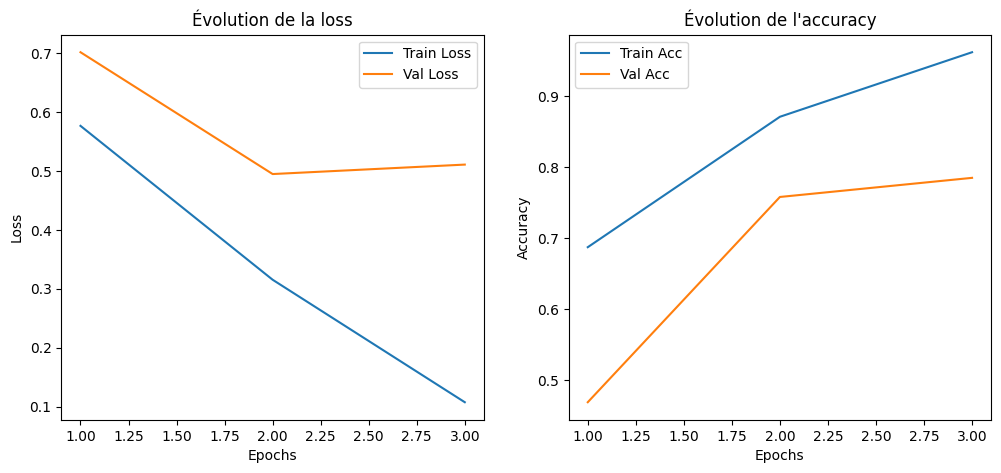

In [9]:
model = CommentClassifier()

trainer = pl.Trainer(
    max_epochs=3, 
    accelerator="gpu" if torch.cuda.is_available() else "cpu", 
    devices=1 if torch.cuda.is_available() else "auto"
)

trainer.fit(model, train_loader, val_loader)

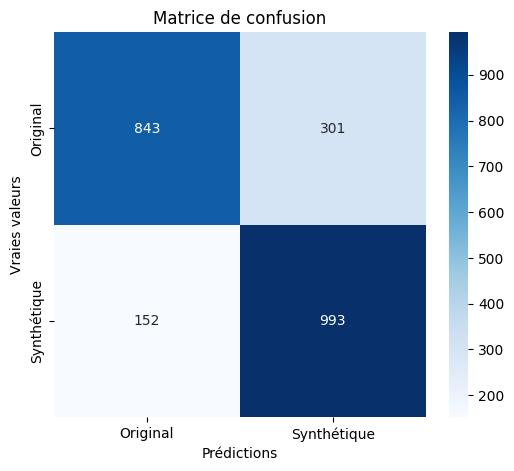

Accuracy: 0.8020969855832241
F1_score: 0.8142681426814268
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.74      0.79      1144
           1       0.77      0.87      0.81      1145

    accuracy                           0.80      2289
   macro avg       0.81      0.80      0.80      2289
weighted avg       0.81      0.80      0.80      2289



In [10]:
test_dataset = CommentDataset(test_df.body.to_numpy(), test_df.label.to_numpy(), tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

model.eval()

# Récupérer les prédictions
y_true, y_pred = get_predictions(model, test_loader)
# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Créer une heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Original", "Synthétique"], yticklabels=["Original", "Synthétique"])
plt.xlabel("Prédictions")
plt.ylabel("Vraies valeurs")
plt.title("Matrice de confusion")
plt.show()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1_score:", f1_score(y_pred=y_pred, y_true=y_true))
print("Classification Report:\n", classification_report(y_true, y_pred))

In [12]:
synth_df_few_shots = pd.read_csv("few_shot_backward_fixed.csv")
synth_df_few_shots['label'] = 1 # Sythetic data
synth_df_few_shots.drop(columns=['score'], inplace=True)
sampled_synth_df_few_shots = synth_df_few_shots.sample(n=1431, random_state=42)

synth_df_BT_1 = pd.read_csv("back_translated_comments-1.csv")
synth_df_BT_1['label'] = 1 # Sythetic data
synth_df_BT_1.drop(columns=['score'], inplace=True)
sampled_synth_df_BT_1 = synth_df_BT_1.sample(n=0, random_state=42)

synth_df_BT_2 = pd.read_csv("back_translated_comments-2.csv")
synth_df_BT_2['label'] = 1 # Sythetic data
synth_df_BT_2.drop(columns=['score'], inplace=True)
sampled_synth_df_BT_2 = synth_df_BT_2.sample(n=0, random_state=42)

synth_df_BT_3 = pd.read_csv("back_translated_comments-3.csv")
synth_df_BT_3['label'] = 1 # Sythetic data
synth_df_BT_3.drop(columns=['score'], inplace=True)
sampled_synth_df_BT_3 = synth_df_BT_3.sample(n=0, random_state=42)

synth_df_llama = pd.read_csv("reform_lama3.1-uncessoredV2.csv")
synth_df_llama['label'] = 1 # Sythetic data
sampled_synth_df_llama = synth_df_llama.sample(n=1431, random_state=42)
sampled_synth_df_llama = sampled_synth_df_llama.rename(columns={'bidy': 'body'})

synth_df_gpt2 = pd.read_csv("gpt2_unif.csv")
synth_df_gpt2['label'] = 1 # Sythetic data
synth_df_gpt2.drop(columns=['score'], inplace=True)
sampled_synth_df_gpt2 = synth_df_gpt2.sample(n=1430, random_state=42)

synth_df_llama_gen = pd.read_csv("Llama32Generate.csv")
synth_df_llama_gen['label'] = 1 # Sythetic data
synth_df_llama_gen.drop(columns=['score'], inplace=True)
sampled_synth_df_llama_gen = synth_df_gpt2.sample(n=1430, random_state=42)

sampled_synth_df = pd.concat([sampled_synth_df_few_shots, sampled_synth_df_BT_1, sampled_synth_df_BT_2, sampled_synth_df_BT_3, 
                              sampled_synth_df_llama, sampled_synth_df_gpt2, sampled_synth_df_llama_gen], axis=0, ignore_index=True)
print(sampled_synth_df.shape)
sampled_synth_df.head()

(5722, 3)


,body,label,score
0,"That's fantastic news, thank you for sharing!",1,NaN
1,That is a really great song. I love it.,1,NaN
2,You might have to get a new one.,1,NaN
3,"You know what, you're absolutely right. That's...",1,NaN
4,What a bunch of fucking losers. I hope they al...,1,NaN


In [13]:
sampled_synth_train_df, sampled_synth_test_df = train_test_split(sampled_synth_df, test_size=0.20, stratify=sampled_synth_df["label"], random_state=42)
sampled_synth_train_df, sampled_synth_valid_df = train_test_split(sampled_synth_train_df, test_size=0.08 / 0.8, stratify=sampled_synth_train_df["label"], random_state=42)

ALL_train_df = pd.concat([orig_train_df, sampled_synth_train_df]).sample(frac=1).reset_index(drop=True)
ALL_train_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(ALL_train_df.shape)
ALL_valid_df = pd.concat([orig_valid_df, sampled_synth_valid_df]).sample(frac=1).reset_index(drop=True)
ALL_valid_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(ALL_valid_df.shape)
ALL_test_df = pd.concat([orig_test_df, sampled_synth_test_df]).sample(frac=1).reset_index(drop=True)
ALL_test_df.drop(columns=['Unnamed: 0', 'comment_id', 'score'], inplace=True)
print(ALL_test_df.shape)

train_df = ALL_train_df
val_df = ALL_valid_df
test_df = ALL_test_df

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Créer les datasets
train_dataset = CommentDataset(train_df.body.to_numpy(), train_df.label.to_numpy(), tokenizer)
val_dataset = CommentDataset(val_df.body.to_numpy(), val_df.label.to_numpy(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

(8239, 2)
(916, 2)
(2289, 2)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | bert    | BertModel        | 109 M  | eval 
1 | dropout | Dropout          | 0      | train
2 | fc      | Linear           | 1.5 K  | train
3 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
109 M     Trainable params
0         Non-trainable params
109 M     Total params
437.935   Total estimated model params size (MB)
3         Modules in train mode
228       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


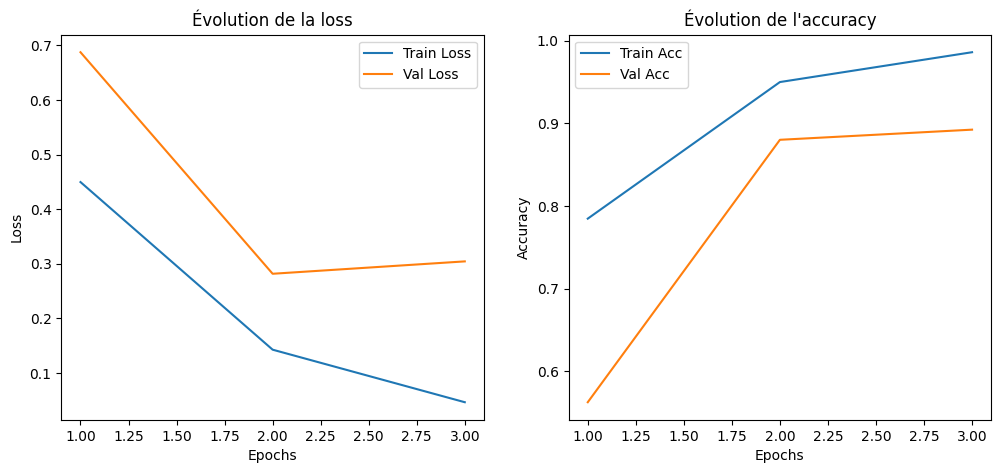

In [14]:
model = CommentClassifier()

trainer = pl.Trainer(
    max_epochs=3, 
    accelerator="gpu" if torch.cuda.is_available() else "cpu", 
    devices=1 if torch.cuda.is_available() else "auto"
)

trainer.fit(model, train_loader, val_loader)

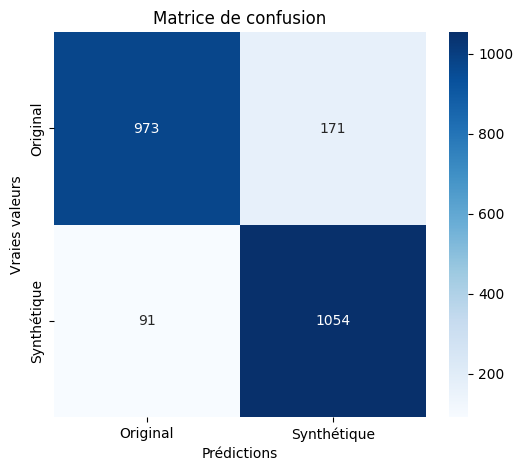

Accuracy: 0.8855395369156837
F1_score: 0.889451476793249
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.85      0.88      1144
           1       0.86      0.92      0.89      1145

    accuracy                           0.89      2289
   macro avg       0.89      0.89      0.89      2289
weighted avg       0.89      0.89      0.89      2289



In [15]:
test_dataset = CommentDataset(test_df.body.to_numpy(), test_df.label.to_numpy(), tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

model.eval()

# Récupérer les prédictions
y_true, y_pred = get_predictions(model, test_loader)
# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Créer une heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Original", "Synthétique"], yticklabels=["Original", "Synthétique"])
plt.xlabel("Prédictions")
plt.ylabel("Vraies valeurs")
plt.title("Matrice de confusion")
plt.show()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1_score:", f1_score(y_pred=y_pred, y_true=y_true))
print("Classification Report:\n", classification_report(y_true, y_pred))

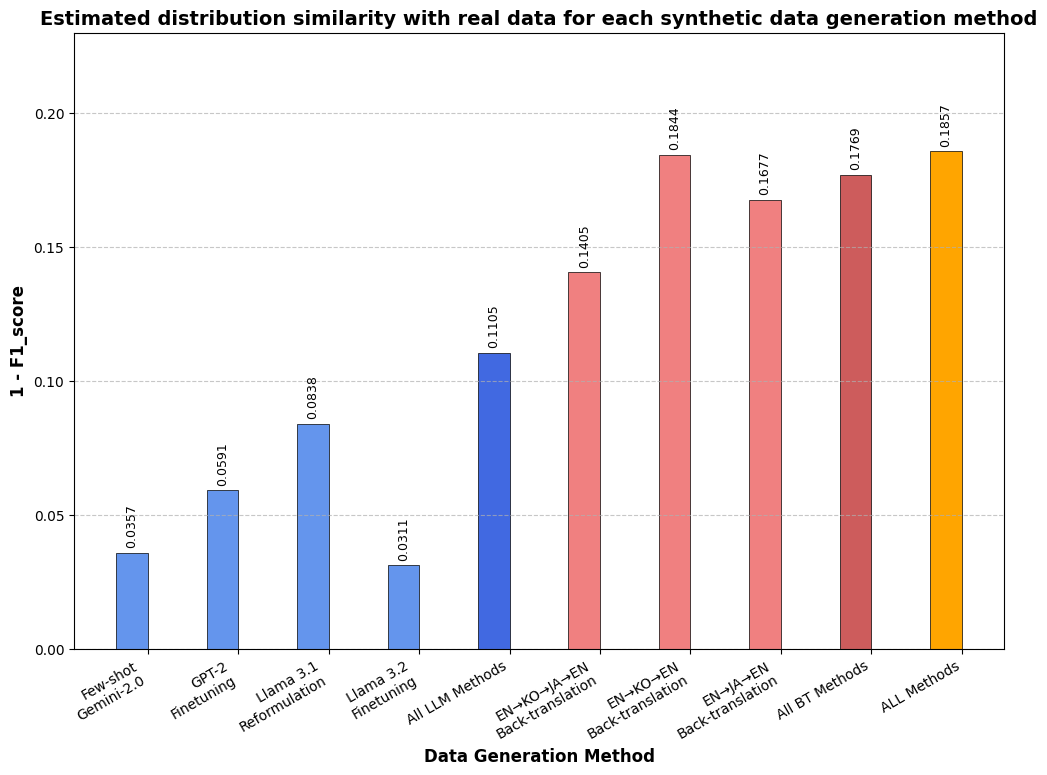

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data from your results
methods = ['Few-shot\nGemini-2.0', 'GPT-2\nFinetuning', 'Llama 3.1\nReformulation', 'Llama 3.2\nFinetuning',  'All LLM Methods',
           'EN→KO→JA→EN\nBack-translation', 'EN→KO→EN\nBack-translation', 'EN→JA→EN\nBack-translation', 'All BT Methods', 'ALL Methods']
hateBERT_rmse = [1-0.9642699602999559, 1-0.9408695652173913, 1-0.9161810847153743, 1-0.9688612099644128, 1-0.889451476793249, 1-0.8594847775175644, 
                 1-0.8156209987195903, 1-0.8323353293413174, 1-0.8230912476722533, 1-0.8142681426814268]
#BERT_rmse = [0.1686091100, 0.1727992111, 0.1693802876, 0.1720299683, 0.1688278839, 0.1694726578, 0.1689775242]

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(12, 8))

# Set width of bars
barWidth = 0.35
positions1 = np.arange(len(methods))
#positions2 = [x + barWidth for x in positions1]

# Create bars
bars1 = ax.bar(positions1, hateBERT_rmse, width=barWidth, label='HateBERT', color='cornflowerblue', edgecolor='black', linewidth=0.5)
# Changer la couleur de la barre "ALL Methods" en orange
for i, label in enumerate(methods):
    if label == 'All LLM Methods':
        bars1[i].set_color('royalblue')
        bars1[i].set_edgecolor('black') 
    if label == 'EN→KO→JA→EN\nBack-translation' or label == 'EN→KO→EN\nBack-translation' or label == 'EN→JA→EN\nBack-translation':
        bars1[i].set_color('lightcoral')
        bars1[i].set_edgecolor('black') 
    if label == 'All BT Methods':
        bars1[i].set_color('indianred')
        bars1[i].set_edgecolor('black')
    if label == 'ALL Methods':
        bars1[i].set_color('orange')
        bars1[i].set_edgecolor('black')  # Pour garder le contour
#bars2 = ax.bar(positions2, BERT_rmse, width=barWidth, label='BERT', color='lightcoral', edgecolor='black', linewidth=0.5)

# Customize the plot
ax.set_xlabel('Data Generation Method', fontweight='bold', fontsize=12)
ax.set_ylabel('1 - F1_score', fontweight='bold', fontsize=12)
ax.set_title('Estimated distribution similarity with real data for each synthetic data generation method', fontweight='bold', fontsize=14)
ax.set_xticks([p + barWidth/2 for p in positions1])
ax.set_xticklabels(methods, rotation=30, ha='right')

# Set y-axis limits to zoom in on the relevant range
# Find min and max values to set appropriate limits with some padding
min_val = min(hateBERT_rmse)
max_val = max(hateBERT_rmse)
# Add 10% padding below min and 10% padding above max
padding = (max_val - min_val) * 0.1
y_min = min_val - padding
y_max = max_val + padding

# Set y-axis limits to zoom in on the relevant range
y_min = 0
y_max = 0.23

ax.set_ylim(y_min, y_max)

# Add a grid for better readability (only horizontal grid lines)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.4f}', ha='center', va='bottom', rotation=90, fontsize=9)

add_labels(bars1)

plt.show()

////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////